In [65]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [66]:
data = mnist.load_data()

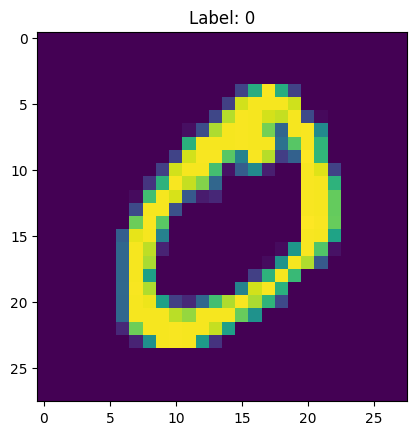

In [67]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1])
plt.title(f"Label: {y_train[1]}")
plt.show()

In [49]:
print(X_train.shape)      # the whole book
print(X_train[0].shape)   # one page (one image)
print(X_train[0][6])      # one row from that image (28 numbers)
print(X_train[0][0][0])   # one single pixel

(60000, 28, 28)
(28, 28)
[  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
 225 172 253 242 195  64   0   0   0   0]
0


In [50]:
print(X_train.shape)
print(y_train[1])

(60000, 28, 28)
0


### so for each image (60000 images) theres a 2d matrix representing the image. its 28x28 pixels so 28x28 row column. totally 28*28 pixels. for feeding it into a neural network we need a 1d array. where the index is the given pixel i believe. Also im one hot encoding y, so instead of the label just being the number 1 or 2 its an array of 10 elements and the given index has 1 instead of 0. doing this since in the end the result will be a probability for 10 different digits so this way we just align it and get the probability.

In [71]:
X_train = X_train.reshape(60000,28*28)
X_test = X_test.reshape(10000,28*28)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

X_train = X_train/255
X_test = X_test/255

In [72]:
np.random.seed(69)
W1 = np.random.randn(784,128)*0.01
W2 = np.random.randn(128,10)*0.01
B1 = np.zeros(128)
B2 = np.zeros(10)

In [73]:
def forward_pass(X):
    Z1 = X@W1 + B1
    A1 = ReLU(Z1)
    Z2 = A1@W2 + B2
    A2 = softmax(Z2)
    return A2,A1,Z1

def ReLU(x):
    return np.maximum(0,x)
def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def compute_loss(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))


def backward_pass(X, y_true, A1, A2, W2, Z1):
    n = X.shape[0]  # 60000
    
    dZ2 = A2 - y_true
    
    dW2 = A1.T @ dZ2 / n
    dB2 = np.sum(dZ2, axis=0) / n
    
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)
    
    dW1 = X.T @ dZ1 / n
    dB1 = np.sum(dZ1, axis=0) / n
    
    return dW1, dB1, dW2, dB2
def update_weights(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate):
    W1 -= learning_rate * dW1
    W2 -= learning_rate * dW2
    B1 -= learning_rate * dB1
    B2 -= learning_rate * dB2

    return W1,B1,W2,B2

In [74]:
for i in range(2000):
    y_pred,A1,Z1 = forward_pass(X_train)
    L = compute_loss(y_pred,y_train)
    dW1,dB1,dW2,dB2 = backward_pass(X_train,y_train,A1,y_pred,W2,Z1)
    W1,B1,W2,B2 = update_weights(W1,B1,W2,B2,dW1,dB1,dW2,dB2,0.01)

    if i%10==0:
        print(L)
    

2.3025524779293494
2.3013805581445785
2.3002024232207954
2.299006484435242
2.2977814742809968
2.296515755227649
2.2951979706690913
2.293816636030571
2.292359780548841
2.2908155898366407
2.2891718317206142
2.287415797000368
2.2855339049094385
2.2835119702646973
2.2813355163786753
2.2789894704835527
2.2764568631147877
2.2737201617649494
2.2707612948461087
2.2675620564782664
2.2641026017215995
2.260361957871007
2.2563180262054026
2.2519482361326837
2.247228842697717
2.2421345162537287
2.23663922829804
2.2307164663437113
2.224338535891316
2.2174767716383457
2.210102389895473
2.2021853010083356
2.1936947998479708
2.184601799688592
2.1748769254517204
2.1644921078285764
2.1534206390384725
2.141636972800637
2.1291180858332552
2.1158432321409406
2.1017951086341626
2.086959739598436
2.07132616695157
2.054888356913246
2.037644665463826
2.0195990368860524
2.000759758258378
1.9811411903999228
1.9607645641730236
1.939657316104231
1.9178521246941378
1.8953883318948057
1.8723106246094716
1.84866922799

In [75]:
y_pred_test, _, _ = forward_pass(X_test)
print(y_pred_test[0])        # the 10 probabilities for image 0
print(np.argmax(y_pred_test[0]))  # what the network thinks it is
print(np.argmax(y_test[0]))       # what it actually is

[1.17850233e-03 1.51054310e-05 3.10357234e-04 2.05994640e-03
 5.48212851e-04 7.12691928e-04 8.85779880e-06 9.62668576e-01
 7.38794079e-04 3.17589559e-02]
7
7


In [76]:
print(np.argmax(y_pred_test[1]))
print(np.argmax(y_test[1]))  

2
2


In [77]:
y_pred_test, _, _ = forward_pass(X_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == true_labels)
print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 87.34%


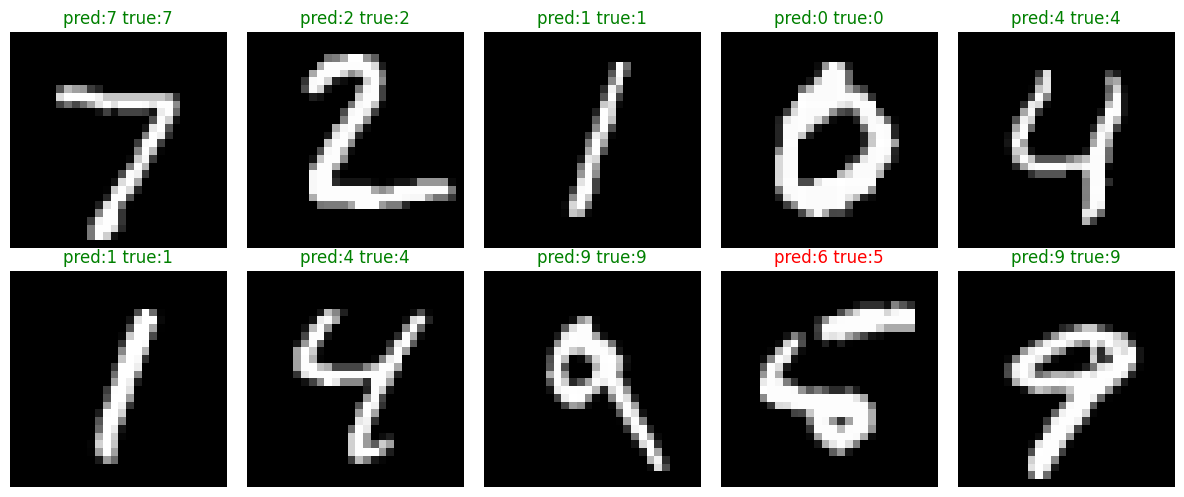

In [78]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img = X_test[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    pred = predictions[i]
    true = true_labels[i]
    color = 'green' if pred == true else 'red'
    ax.set_title(f"pred:{pred} true:{true}", color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

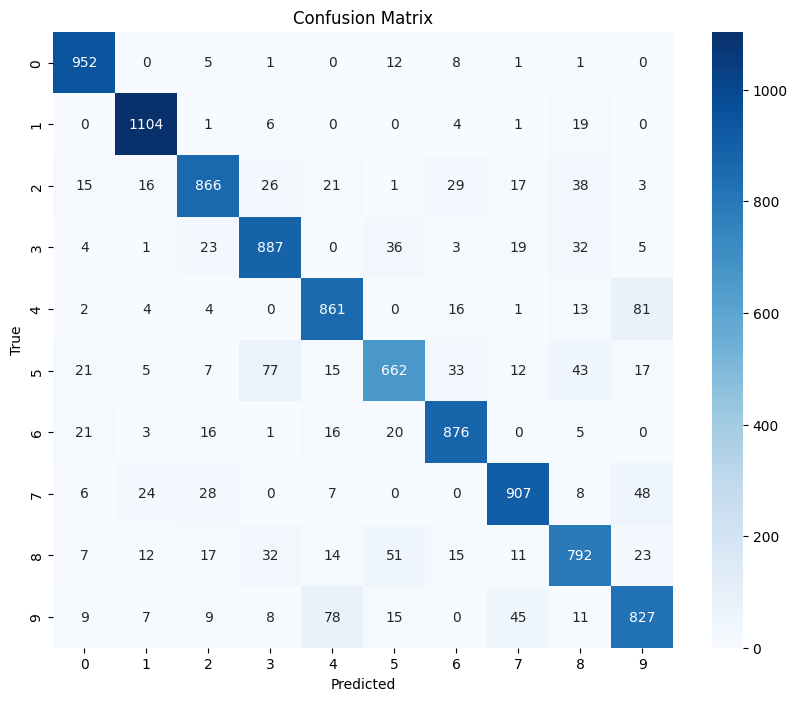

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [81]:
for digit in range(10):
    mask = true_labels == digit
    class_acc = np.mean(predictions[mask] == true_labels[mask])
    print(f"Digit {digit}: {class_acc * 100:.2f}%")

Digit 0: 97.14%
Digit 1: 97.27%
Digit 2: 83.91%
Digit 3: 87.82%
Digit 4: 87.68%
Digit 5: 74.22%
Digit 6: 91.44%
Digit 7: 88.23%
Digit 8: 81.31%
Digit 9: 81.96%


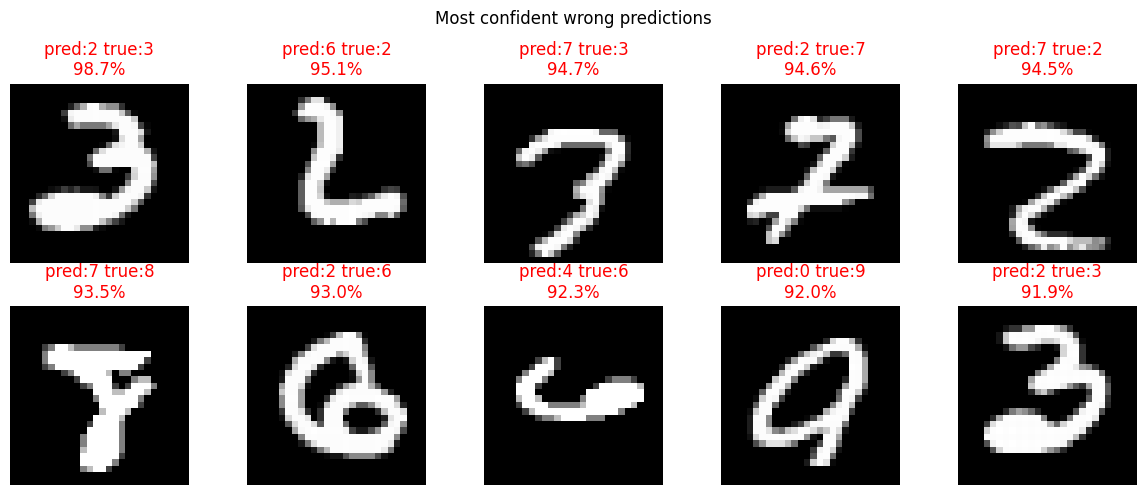

In [82]:
wrong_idx = np.where(predictions != true_labels)[0]
confidences = np.max(y_pred_test, axis=1)
wrong_confidences = confidences[wrong_idx]
top_wrong = wrong_idx[np.argsort(wrong_confidences)[::-1][:10]]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = top_wrong[i]
    img = X_test[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"pred:{predictions[idx]} true:{true_labels[idx]}\n{confidences[idx]*100:.1f}%", color='red')
    ax.axis('off')
plt.suptitle("Most confident wrong predictions")
plt.tight_layout()
plt.show()

In [83]:
from sklearn.metrics import classification_report
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       980
           1       0.94      0.97      0.96      1135
           2       0.89      0.84      0.86      1032
           3       0.85      0.88      0.87      1010
           4       0.85      0.88      0.86       982
           5       0.83      0.74      0.78       892
           6       0.89      0.91      0.90       958
           7       0.89      0.88      0.89      1028
           8       0.82      0.81      0.82       974
           9       0.82      0.82      0.82      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



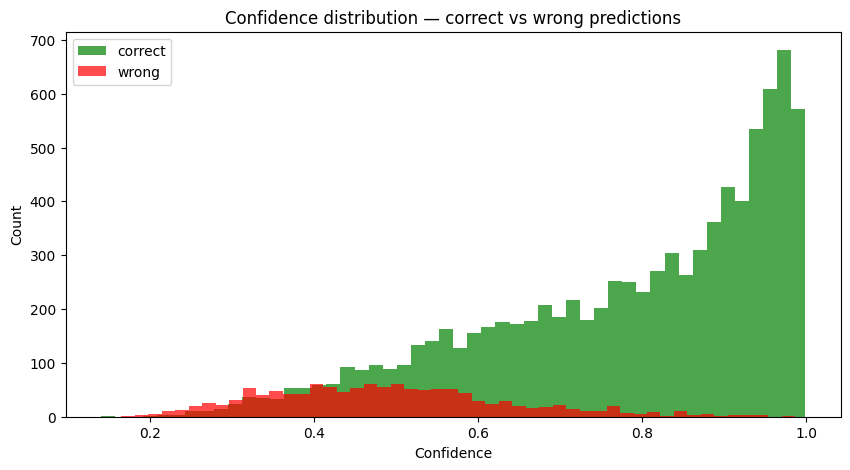

In [84]:
correct_mask = predictions == true_labels
correct_conf = confidences[correct_mask]
wrong_conf = confidences[~correct_mask]

plt.figure(figsize=(10, 5))
plt.hist(correct_conf, bins=50, alpha=0.7, color='green', label='correct')
plt.hist(wrong_conf, bins=50, alpha=0.7, color='red', label='wrong')
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence distribution — correct vs wrong predictions")
plt.legend()
plt.show()